# Atividade ROS

### **Informações do Aluno**

**Nome:** João Pedro Gonçalves Corrêa Araujo
**Turma:** Eng Comp - T16

### **Objetivo**

Desenvolva um algoritmo para ler, processar e extrair contornos de uma imagem e um pacote ROS 2
em Python que faz a tartaruga do turtlesim percorrer o contorno extraído — desenhando-a na tela.
Toda a inteligência de visão computacional deve ser implementada por você, do zero.

## ETAPA 1-4 - Traçando rota para o TurtleBot

Nessa etapa, o objetivo foi traçar a rota antes de ser enviado posteriormente a ser desenhada pelo ROS.


### 1 - Pré-Processamento

O primeiro passo é importar as bibliotecas necessários para desenvolvimento do projeto. Foram importadas as bibliotecas: **opencv** para ler a imagem, **numpy** para fazer operações matriciais nos pixeis da imagem e **matplotlib** para exibir o estado da imagem passo a passo.


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Depois disso, carregamos a imagem original do arquivo e convertendo-a manualmente de colorida para escala de cinza. O código separa as matrizes dos três canais de cor da imagem (Azul, Verde e Vermelho) e multiplica cada canal por um peso matemático específico. Isso é feito porque o olho humano percebe a luminosidade de cada cor de forma diferente. <br><br>
Em seguida, essas três matrizes são somadas para transformar a imagem em uma única matriz de tons de cinza, que no fim é exibida na tela.

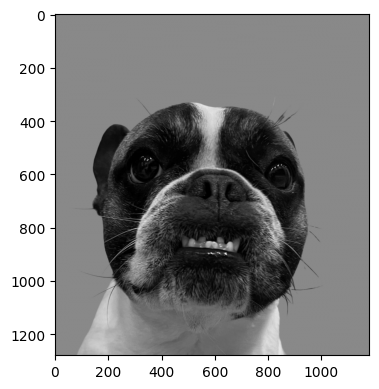

In [3]:

img = cv2.imread('zara.png') 

# O primeiro passo para alterar para escala de cinza, é alterar a cor da imagem para os valores em RGB que o ser humano enxerga como cinza.

AltR = 0.299
AltG = 0.587
AltB = 0.114

# Função para alterar RGB
def transformaEscalaCinza(img):

    # Pega valores atual da imagem
    B, G, R = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    # Aplica alteração para cinza
    novoR = AltR * R
    novoG = AltG * G
    novoB = AltB * B

    # Retorna imagem com cor
    cinza = (novoR + novoG + novoB).astype(np.uint8)

    # Usa matplotlib para exibir cachorro em escala de cinza
    plt.subplots(1, 1, figsize=(12, 4))
    plt.imshow(cinza, cmap='gray')
    plt.tight_layout(); 
    plt.show()
    return cinza

cinza = transformaEscalaCinza(img)

### 2 - Detecção de Bordas

Depois de aplicar a escala de cinza, o objetivo agora é começar a detectar as bordas do nossa imagem para definir os limites que nosso turtlesim irá passar! O objetivo aqui é criar uma função que recebe uma imagem e outra matriz base a ser aplicada nos pixeis, com objetivo de gerar uma terceira imagem entre os dois.

A função abaixo passa pixel por pixel da imagem enviada como parâmetro, com uma matriz 3x3 que aplica uma alteração na imagem original, gerando uma terceira imagem.

In [4]:
# Cria função para aplicar convulação

def convolucao_manual(imagem, kernel):
    h, w = imagem.shape
    pad = np.pad(imagem, 1, mode='constant')
    saida = np.zeros_like(imagem, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            saida[i, j] = np.sum(pad[i:i + 3, j:j + 3] * kernel)
    return saida

A função abaixo inverte as cores da imagem, passa pixel por pixel verificando, se ele for menor que 100 (ou seja, escuro), ele troca para para branco. O que for acima de 100 ele transforma em preto, assim destacando o fundo do cachorro e permitindo destacar o cachorro e detectar as bordas da nossa imagem.

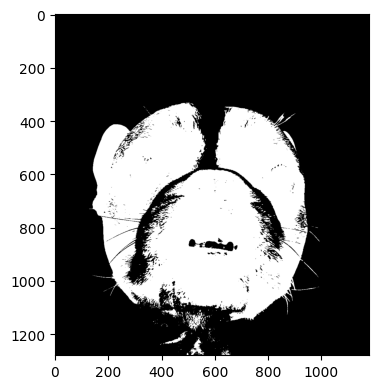

In [5]:


# A função abaixo inverte as cores da imagem, passa pixel por pixel verificando, se ele for menor que 100 (ou seja, escuro), ele troca para para branco. 
# O que for acima de 100 ele transforma em preto, assim destacando o fundo do cachorro

mascara = (cinza < 100).astype(np.uint8)

# Visualização da evolução do pré-processamento
plt.subplots(1, 1, figsize=(15, 4))
plt.imshow(mascara, cmap='gray');        
plt.tight_layout(); plt.show()

O próximo passo é utilizar a função de convolução para varrer a nossa imagem e encontrar exatamente onde estão os limites do desenho. Para isso, criamos duas matrizes 3x3 (chamadas de Kx e Ky). A primeira matriz é especialista em encontrar variações bruscas na horizontal (como as laterais do desenho), enquanto a segunda foca nas variações na vertical (como o topo e a base). Essas matrizes são baseadas no operador de Sobel.

Ao passarmos a nossa máscara por essas duas matrizes usando a função de convolução criada anteriormente, obtemos duas novas imagens separadas: uma destacando apenas os contornos verticais encontrados e outra destacando apenas os horizontais.

<br>
<p> Imagem 1: Matriz de Sobel</p>
<img src="assets/Sobel.png">
<br>
<br>

Como a silhueta do nosso alvo possui várias curvas e diagonais, precisamos juntar esses dois resultados para não perder nenhum pedaço do traçado. Usamos um cálculo matemático (Pitágoras) para unir as forças desses dois eixos em uma única imagem, que chamamos de "magnitude". O resultado é um mapa unificado onde o contorno completo do objeto fica brilhante.

Para garantir que a nossa tartaruga tenha um caminho perfeito, limpo e sem borrões para seguir, fazemos uma última etapa de binarização. O código define uma regra simples: qualquer pixel com uma força de borda maior que 0.5 se transforma em branco, e tudo abaixo disso vira preto, assim destando o caminho que nosso turtlesim deve seguir.

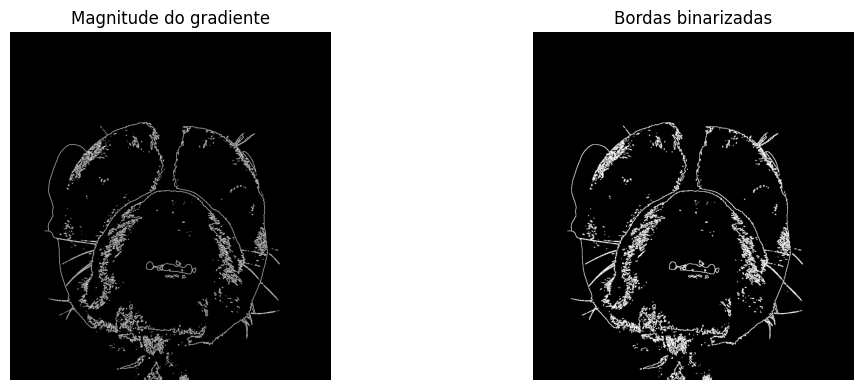

In [6]:
# Cria as matrizes que procuram variações bruscas de preto para branco
Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

# Aplica a convolucao da matriz de Sobel em toda a imagem
Gx = convolucao_manual(mascara, Kx)
Gy = convolucao_manual(mascara, Ky)

# Junta os pixels dos dois eixos identificados pela convolução
magnitude = np.sqrt(Gx ** 2 + Gy ** 2)

# Se a força da borda for maior que 0.5 vira branco, senão vira preto.
bordas = (magnitude > 0.5).astype(np.uint8)

# Exibe as imagens após aplicar 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(magnitude, cmap='gray'); ax[0].set_title('Magnitude do gradiente'); ax[0].axis('off')
ax[1].imshow(bordas, cmap='gray');    ax[1].set_title('Bordas binarizadas');     ax[1].axis('off')
plt.tight_layout(); plt.show()

### 3- Planejamento de Caminho

Nessa etapa, o objetivo é usar a imagem que tratamos até agora, para definir o caminho a ser enviado para o turtlesim.

Primeiro, o código extrai as coordenadas de todos os pixels que formam o contorno da imagem. Como a imagem original possui milhares de pixels e o simulador usa um mapa pequeno (de 0 a 11), aplicamos uma conversão para reduzir e encaixar o desenho no espaço do turtlesim, invertendo também o eixo vertical.

Em seguida, para evitar que a tartaruga pule de um lado para o outro de forma aleatória, aplicamos a lógica do "vizinho mais próximo". O algoritmo reorganiza a lista de coordenadas ligando sempre um ponto ao seu vizinho mais perto, transformando pixels soltos em um caminho único e contínuo.

In [ ]:
# Encontra os índices (linha, coluna) onde o pixel é borda 
indices = np.argwhere(bordas == 1)
altura, largura = bordas.shape
pontos_turtlesim = []

# Mapeia os pixels para o espaço do Turtlesim 
for linha, coluna in indices:
    x_turtle = (coluna / largura) * 11.0
    y_turtle = 11.0 - ((linha / altura) * 11.0)
    pontos_turtlesim.append([x_turtle, y_turtle])

# Algoritmo do Vizinho Próximo (Garante um traçado contínuo)
pontos_ordenados = []
lista_original = pontos_turtlesim.copy()

# Começa pelo primeiro ponto detectado
ponto_atual = lista_original.pop(0)
pontos_ordenados.append(ponto_atual)

while len(lista_original) > 0:
    # Calcula a distância euclidiana do ponto atual para todos os outros restantes
    distancias = np.linalg.norm(np.array(lista_original) - ponto_atual, axis=1)
    
    # Encontra o índice do vizinho mais próximo
    indice_proximo = np.argmin(distancias)
    
    # Atualiza o ponto atual e remove da lista de busca
    ponto_atual = lista_original.pop(indice_proximo)
    pontos_ordenados.append(ponto_atual)

    # Salva as coordenadas no arquivo que o nó do ROS 2 vai ler
nome_arquivo = 'caminho_tartaruga.txt'
np.savetxt(nome_arquivo, pontos_ordenados, delimiter=',')


pts_plot = np.array(pontos_ordenados)
plt.figure(figsize=(6, 6))
# Desenha a linha simulando o rastro do robô
plt.plot(pts_plot[:, 0], pts_plot[:, 1], color='green', linewidth=2, label='Rastro do Robô')
# Marca o ponto de início (verde) e fim (vermelho)
plt.scatter(pts_plot[0, 0], pts_plot[0, 1], color='blue', s=100, zorder=5, label='Início')
plt.scatter(pts_plot[-1, 0], pts_plot[-1, 1], color='red', s=100, zorder=5, label='Fim')

plt.title('Simulação do Caminho no Espaço Turtlesim')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.xlabel('Eixo X (0 a 11)')
plt.ylabel('Eixo Y (0 a 11)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Por fim, essa rota ordenada é salva em um arquivo de texto, que servirá de mapa de navegação para o nó do ROS 2. O código ainda exibe um gráfico na tela simulando o trajeto final, com os pontos de início e fim demarcados, permitindo uma validação visual rápida antes de ligar o robô.

### 4 - Controle ROS2



Após a extração e ordenação das coordenadas da para traçar a rota, entramos na fase de execução prática do movimento. Para isso, criamos um nó de controlo no ROS 2 que lê o ficheiro de coordenadas gerado e guia o robô (`turtlesim`) de ponto em ponto até completar o desenho.

O código de movimentação do turtlesim pode ser encontrado em:

```
./tartaruga/tartaruga/__init__.py
```

Ao iniciar, ele carrega a lista de pontos e cria duas conexões: uma para receber a posição atual da tartaruga e outra para enviar os comandos de velocidade. O controle de movimento funciona em um ciclo contínuo que calcula a distância e o ângulo entre o robô e o próximo alvo desejado. Se a distância até o ponto for menor que 0.2, ele é considerado alcançado, removido da lista, e o robô passa a buscar a coordenada seguinte.

Para se mover, o código utiliza matemática básica para garantir que o robô gire sempre pelo lado mais curto. Além disso, para manter linhas precisas no desenho, a tartaruga rotaciona primeiro e só acelera para a frente quando já está alinhada com o destino. Quando a lista de pontos termina, o nó envia um comando de velocidade zero, parando o robô e finalizando o processo.

### 5 - Vídeo de Demonstração

[Assista o vídeo de demonstração](https://youtu.be/B_S2ougmi9M)